# Financial Performance Prediction

本 Notebook 汇总本项目的输入审计、EDA、交叉验证、模型训练结果、OOF 融合、会计后处理和 submission 校验。所有表格和图形均从 `results/` 与 `figures/` 读取，避免手工抄写实验数值。

In [1]:
from pathlib import Path
import hashlib
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
RESULTS = ROOT / 'results'
TABLES = RESULTS / 'tables'
FIGURES = ROOT / 'figures'
DELIVERABLES = ROOT / 'deliverables'

def show_table(path, n=10):
    df = pd.read_csv(path)
    display(df.head(n))
    return df

def show_fig(name):
    path = FIGURES / name
    display(Image(filename=str(path)))
    return path

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()


## 1. 输入文件与环境审计

In [2]:
manifest = json.loads((RESULTS / 'input_manifest.json').read_text(encoding='utf-8'))
environment = json.loads((RESULTS / 'environment_audit.json').read_text(encoding='utf-8'))
print('Python:', environment['python_version'])
print('Executable:', environment['python_executable'])
print('Missing packages:', environment['missing_packages'])
pd.DataFrame(list(manifest['raw_files'].values())).loc[:, ['name', 'size_bytes', 'sha256']]

Python: Python 3.10.20
Executable: D:\Anaconda\envs\QuantEnv\python.exe
Missing packages: ['xgboost', 'lightgbm', 'optuna', 'jupyter']


,name,size_bytes,sha256
0,train.csv,3455035,fc0d1fab1ed7b597cc900e1e724dc4847814fba7aa04dd...
1,test.csv,816771,a1003ff8a6f90a971e17d473781fff84621131f342f0e3...
2,sample_submission.csv,9291,874682cab231f9e48b6c038ac4859213ebf70453bf390c...
3,data_dictionary.txt,7425,ba3697c21555558bb831d33da97b35b420558f2494530d...
4,说明.docx,15737,c4e71f313214b7fe2fe1542d53a58ad75621e2f09875d5...


## 2. Schema 与数据质量审计

In [3]:
schema = show_table(TABLES / 'schema_summary.csv')
missing = show_table(TABLES / 'missing_rate_by_column.csv', n=8)
duplicates = show_table(TABLES / 'duplicate_summary.csv')
target_summary = show_table(TABLES / 'target_summary.csv')

,dataset,rows,cols,id_unique,missing_cells,missing_rate,numeric_cols,object_cols,feature_cols,target_cols
0,train,1624,212,True,19283,0.056008,208,4,202,9
1,test,406,203,True,5791,0.070264,199,4,202,0
2,sample_submission,406,10,True,0,0.000000,10,0,0,0


,column,group,in_train,in_test,train_missing_rate,test_missing_rate,combined_missing_rate
0,Id,id,True,True,0.0,0.0,0.0
1,Q0_COST_OF_REVENUES,target,True,False,0.0,NaN,0.0
2,Q0_EBITDA,target,True,False,0.0,NaN,0.0
3,Q0_GROSS_PROFIT,target,True,False,0.0,NaN,0.0
4,Q0_OPERATING_EXPENSES,target,True,False,0.0,NaN,0.0
5,Q0_OPERATING_INCOME,target,True,False,0.0,NaN,0.0
6,Q0_REVENUES,target,True,False,0.0,NaN,0.0
7,Q0_TOTAL_ASSETS,target,True,False,0.0,NaN,0.0


,scope,duplicate_rows,duplicate_groups,max_group_size,notes
0,train_non_id,16,2,10,exact duplicate rows within the same dataset s...
1,train_common_features,16,2,10,exact duplicate rows within the same dataset s...
2,test_common_features,2,1,3,exact duplicate rows within the same dataset s...
3,train_rows_matching_test_common_features,18,2,10,train rows whose common feature hash also appe...
4,test_rows_matching_train_common_features,4,2,3,test rows whose common feature hash also appea...


,target,count,missing,mean,std,min,p01,p05,median,p95,p99,max,skew,kurtosis,positive_rate
0,Q0_TOTAL_ASSETS,1624,0,4.797691e+09,2.636638e+10,-1.953310e+11,-5.165367e+09,3.144153e+06,631705500.0,2.246230e+10,9.940675e+10,3.848300e+11,4.361163,64.176265,0.982759
1,Q0_TOTAL_LIABILITIES,1624,0,3.200071e+09,1.624373e+10,-1.399650e+11,-2.728408e+09,2.063379e+06,291650000.0,1.495866e+10,6.771053e+10,2.127170e+11,7.271118,92.252952,0.982759
2,Q0_TOTAL_STOCKHOLDERS_EQUITY,1624,0,1.289882e+09,1.169109e+10,-9.784800e+10,-6.499674e+09,-1.273960e+08,247001000.0,7.859839e+09,3.747282e+10,1.807181e+11,0.312256,82.604134,0.863300
3,Q0_GROSS_PROFIT,1624,0,4.240823e+08,1.817923e+09,-9.170000e+08,-9.497576e+07,-4.746000e+05,37557000.0,1.578177e+09,7.330650e+09,3.718600e+10,11.095203,165.701053,0.892857
4,Q0_COST_OF_REVENUES,1624,0,6.584900e+08,3.085667e+09,-1.587300e+10,-7.685784e+07,0.000000e+00,25135986.0,2.891165e+09,1.275349e+10,5.074900e+10,9.296326,107.654959,0.829433
5,Q0_REVENUES,1624,0,1.062931e+09,4.041767e+09,-3.850000e+08,0.000000e+00,1.824625e+04,92668000.0,4.010000e+09,2.168470e+10,4.904800e+10,7.725059,68.847404,0.963670
6,Q0_OPERATING_INCOME,1624,0,9.842535e+07,6.310543e+08,-2.654000e+09,-9.633219e+08,-9.952270e+07,-200146.5,5.609700e+08,2.238390e+09,1.374800e+10,10.275710,170.696261,0.483990
7,Q0_OPERATING_EXPENSES,1624,0,3.557741e+08,1.553039e+09,-2.403000e+07,1.465149e+05,1.072103e+06,46144500.0,1.397880e+09,5.578930e+09,4.111800e+10,15.217224,331.274201,0.997537
8,Q0_EBITDA,1624,0,6.830815e+07,1.438216e+09,-3.282900e+10,-1.706610e+09,-2.169213e+08,-700000.0,5.445237e+08,3.273746e+09,3.413800e+10,1.539007,370.753603,0.453818


## 3. EDA 图表

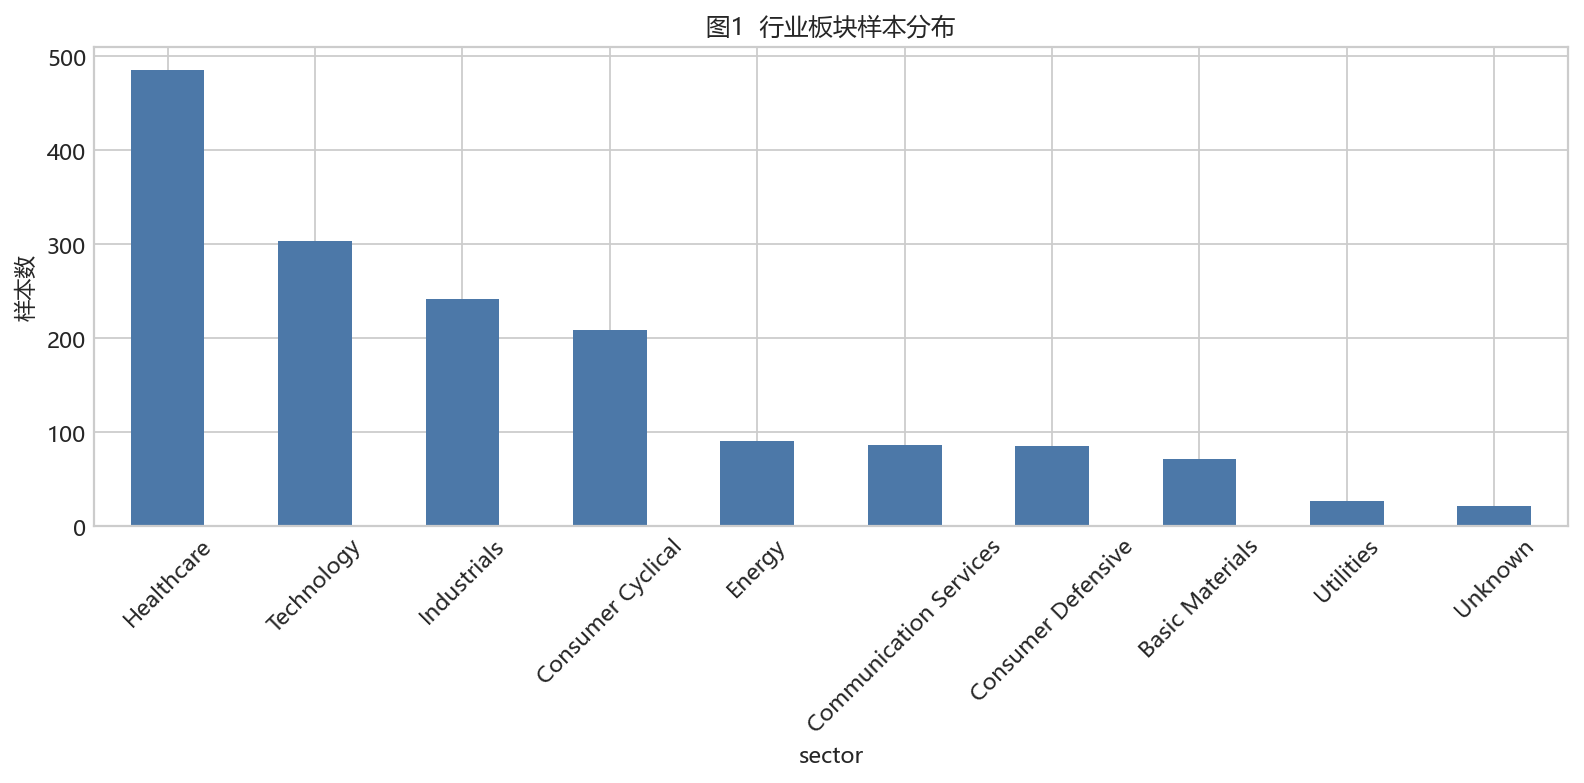

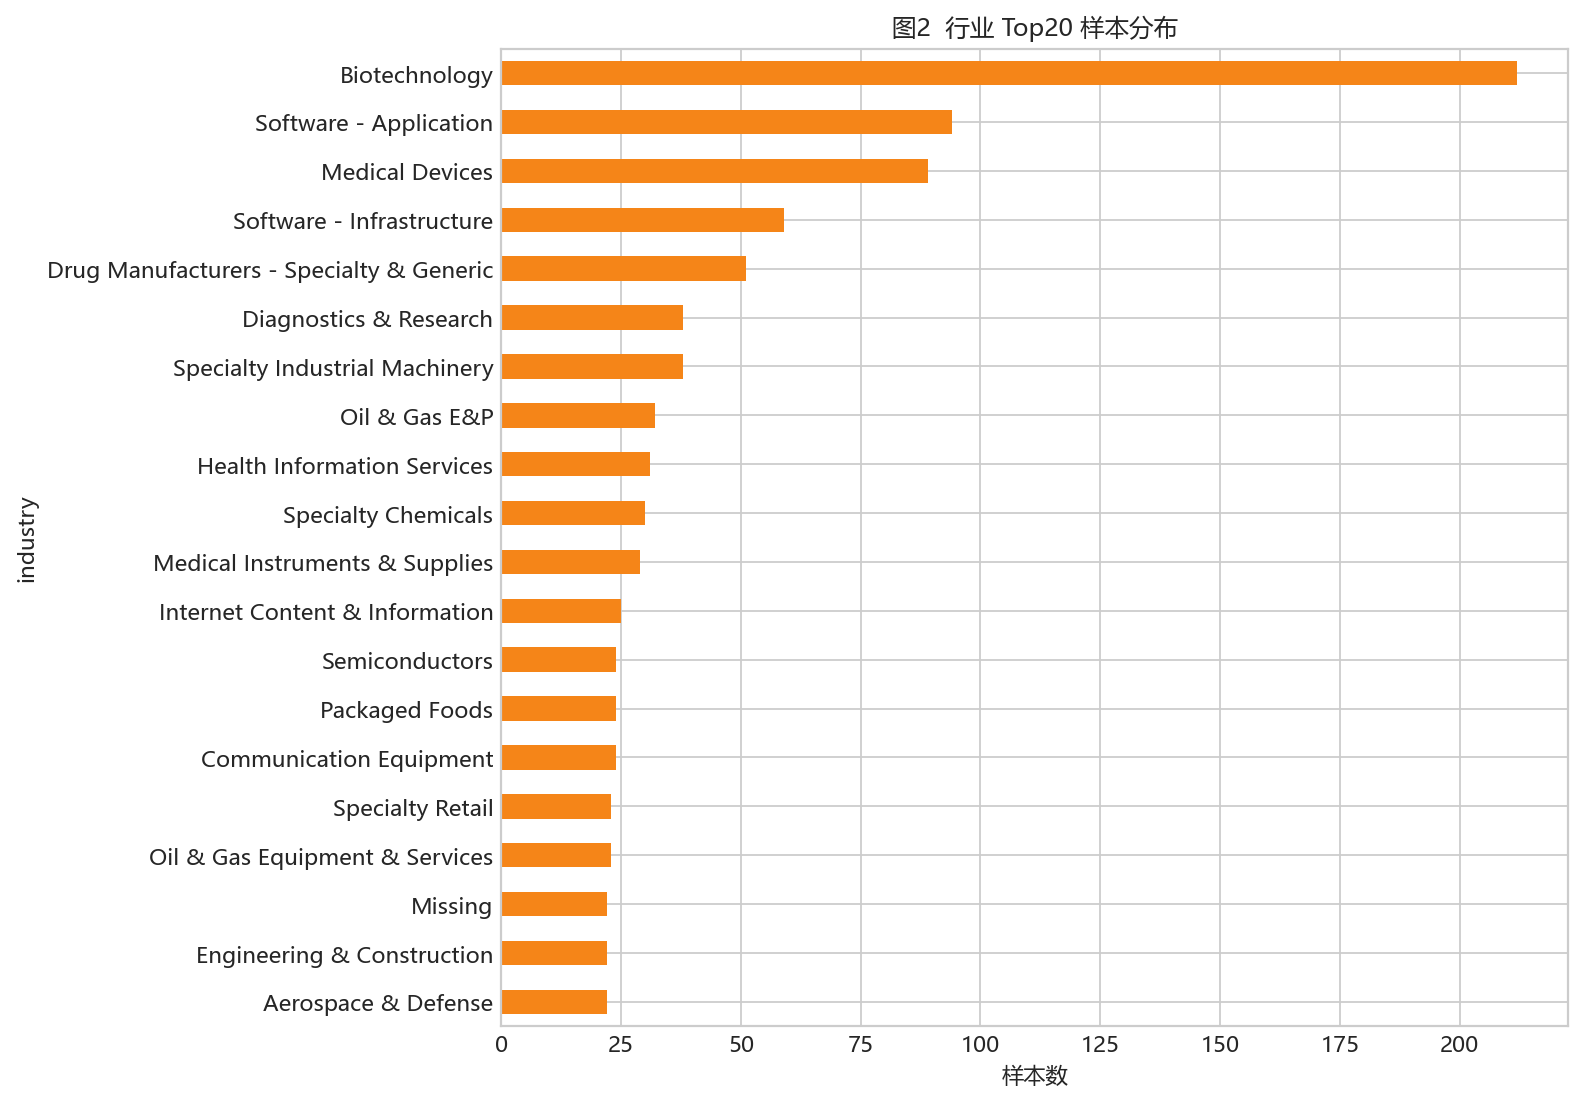

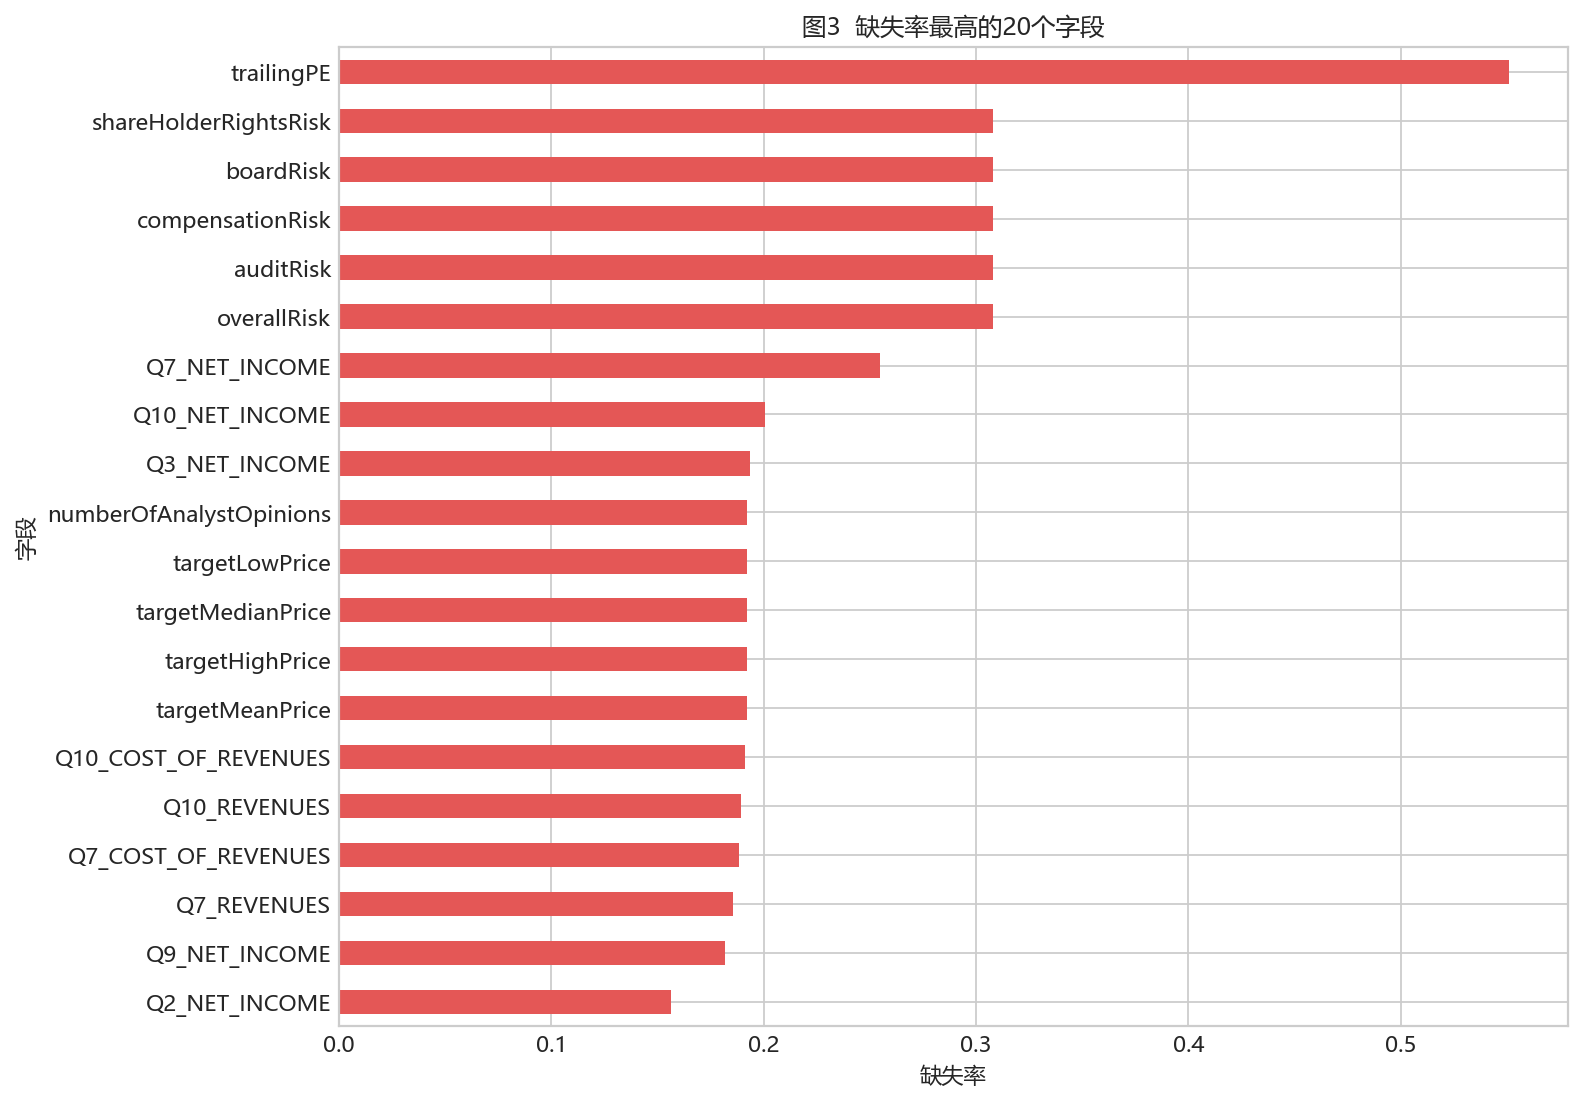

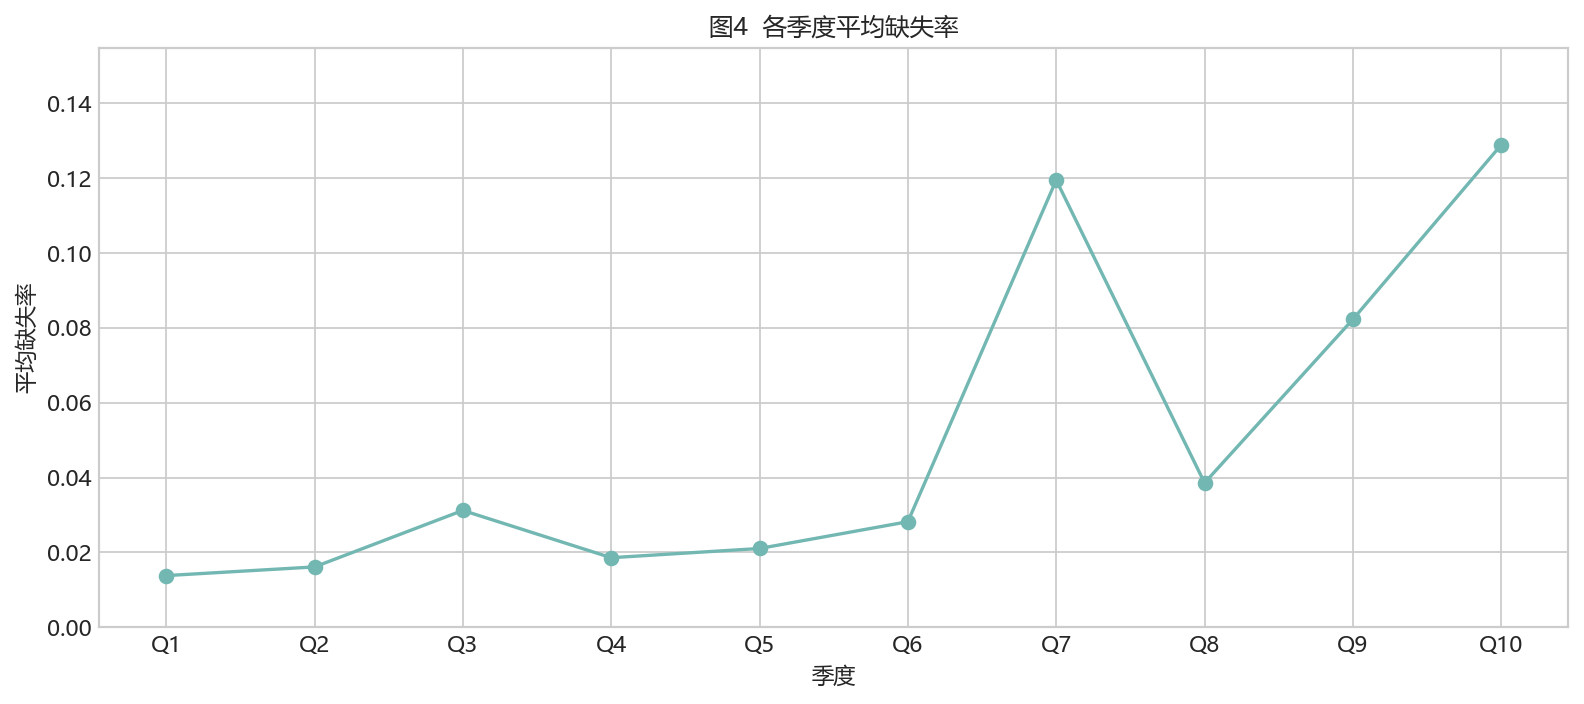

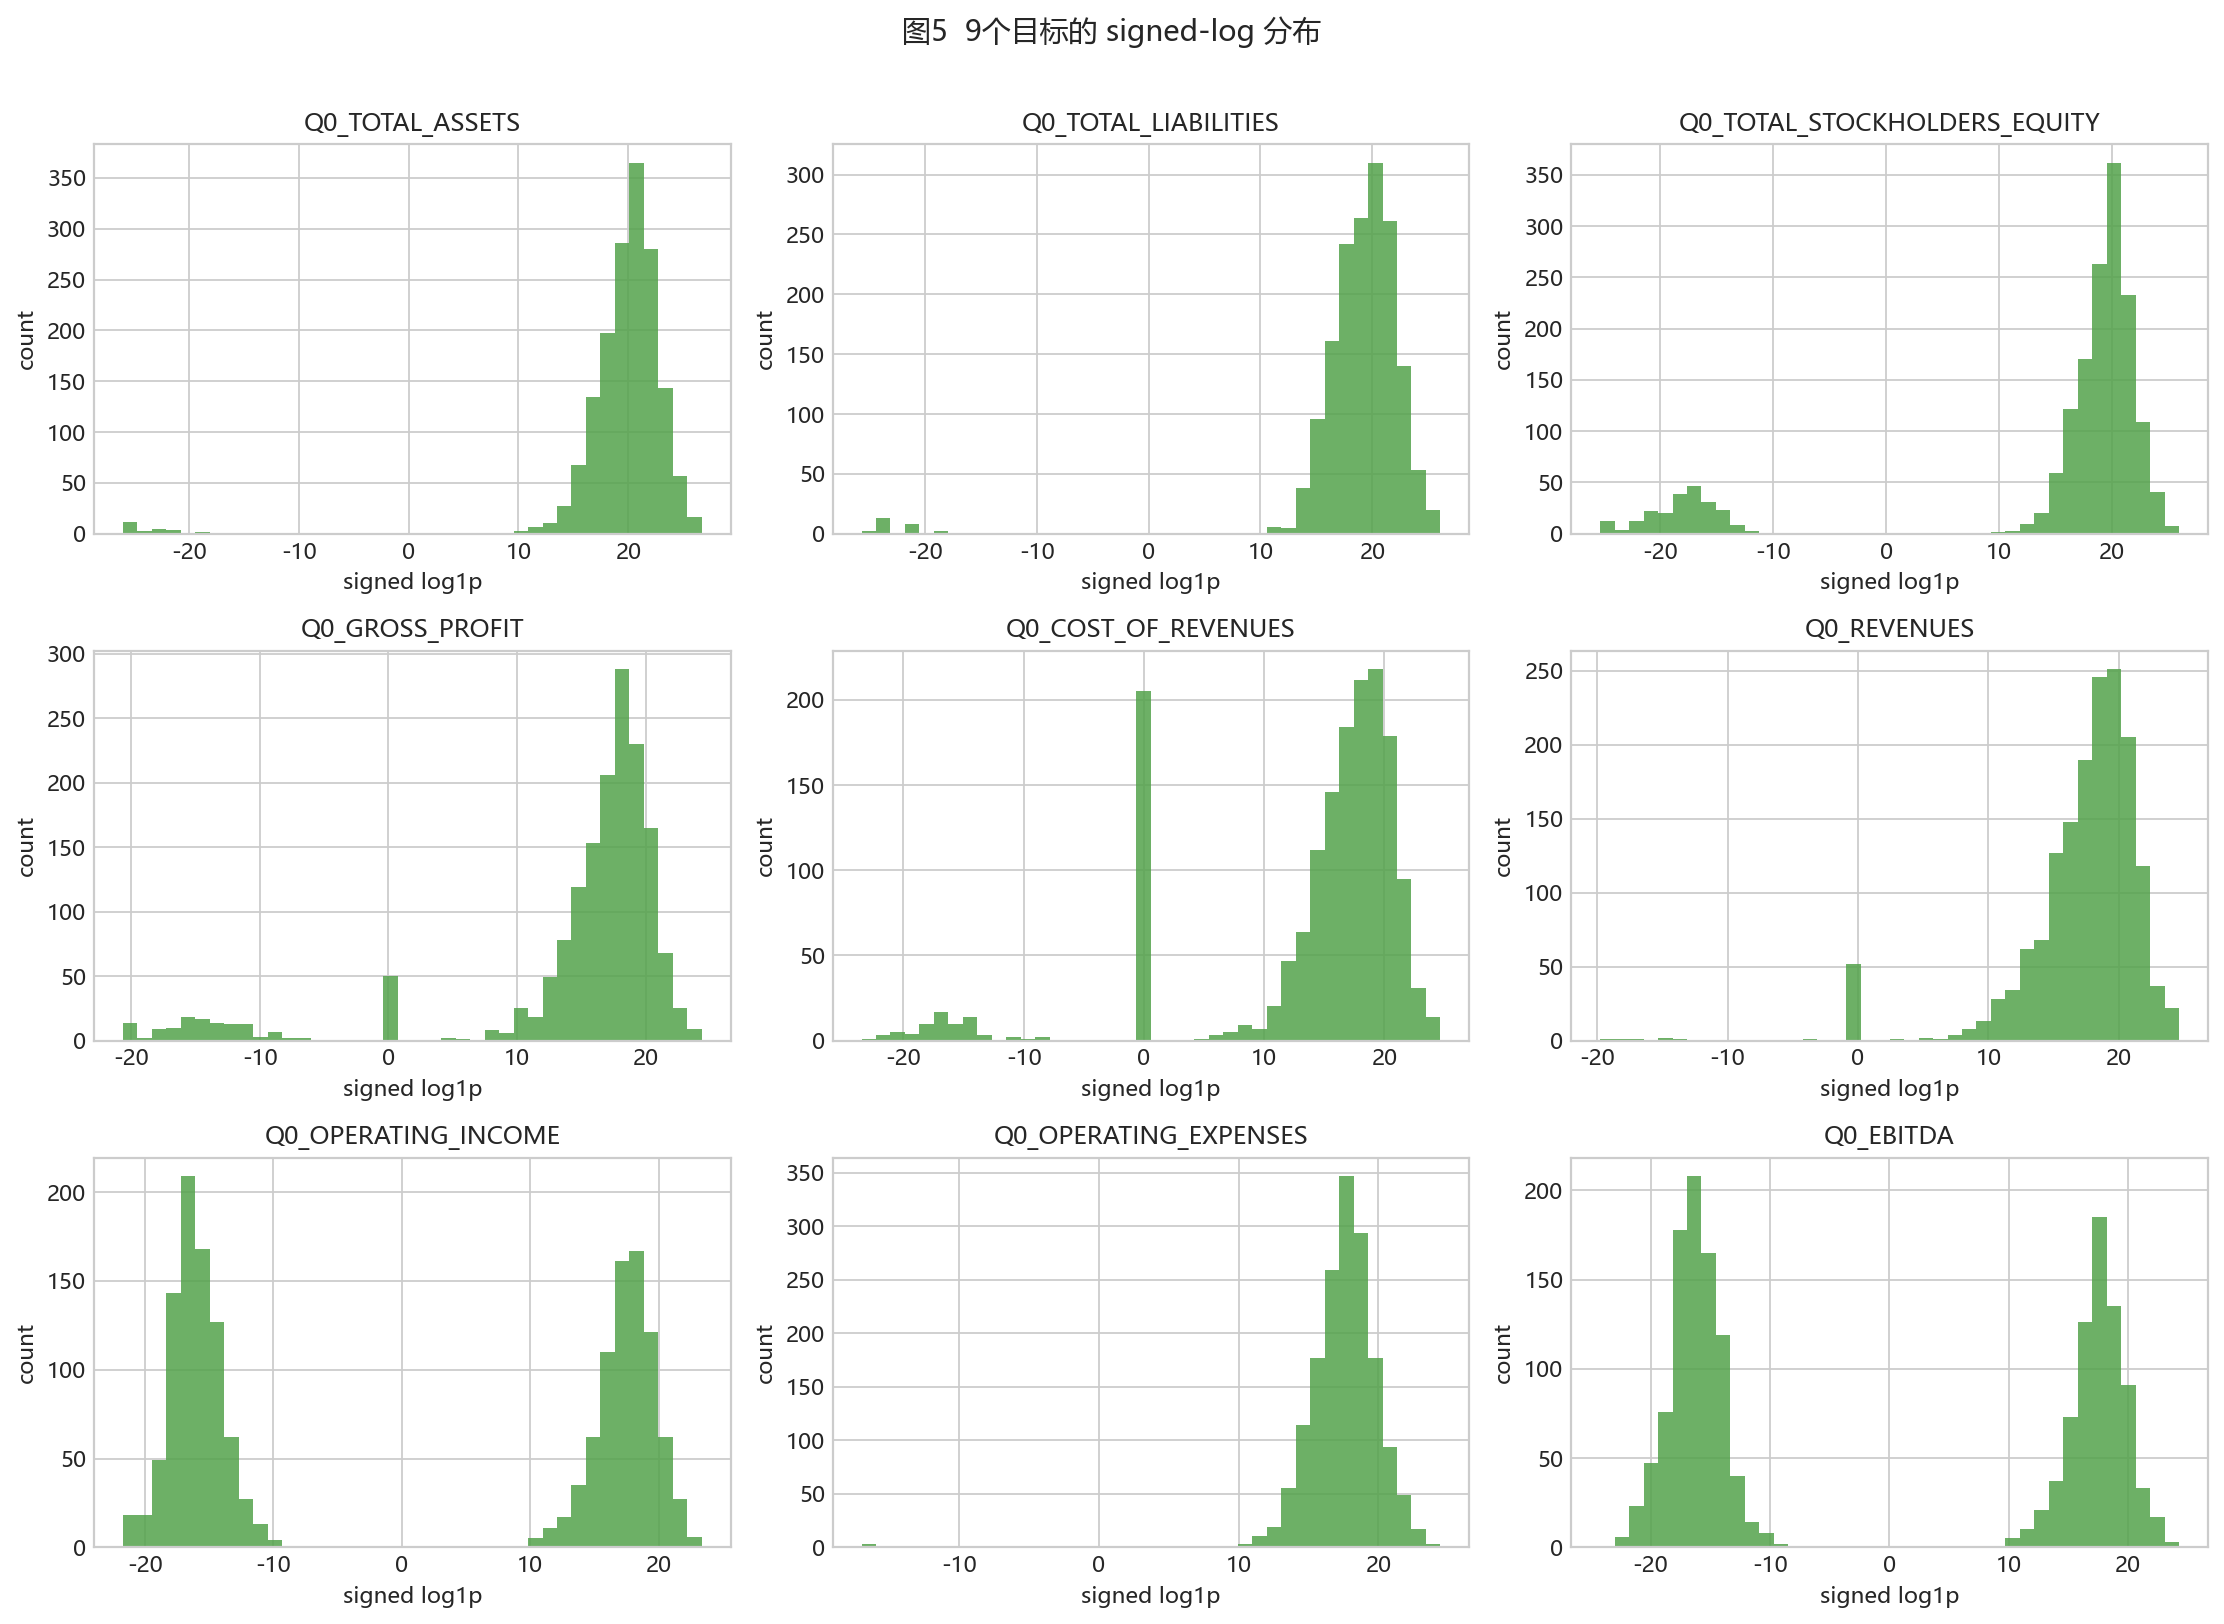

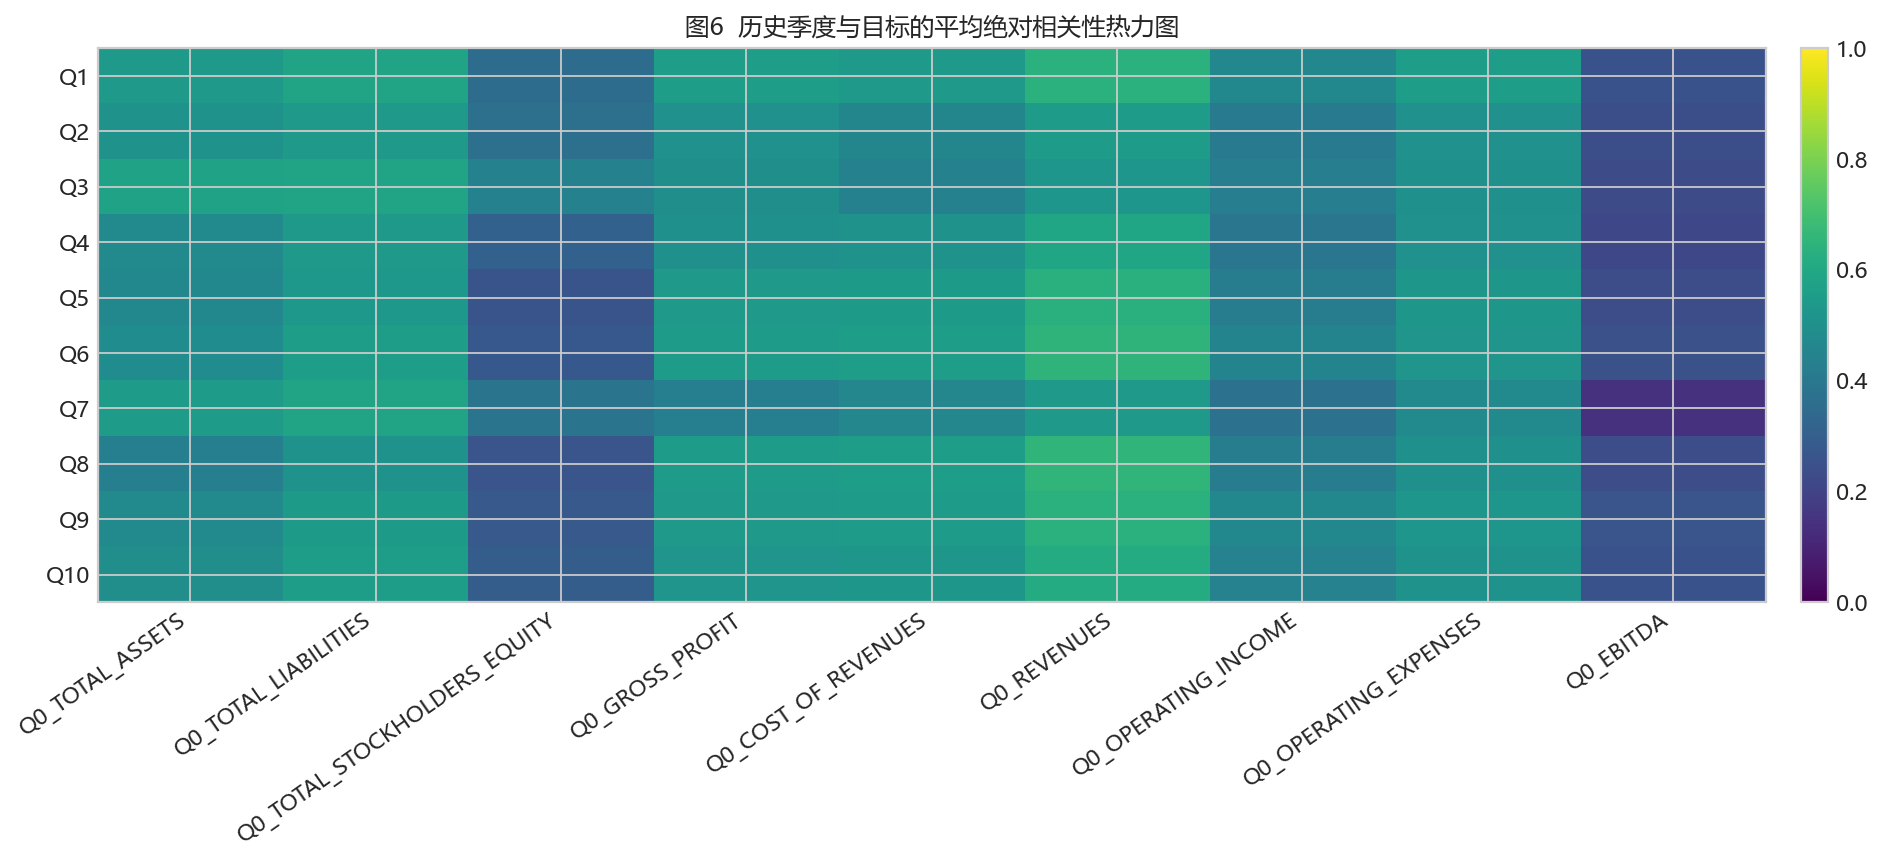

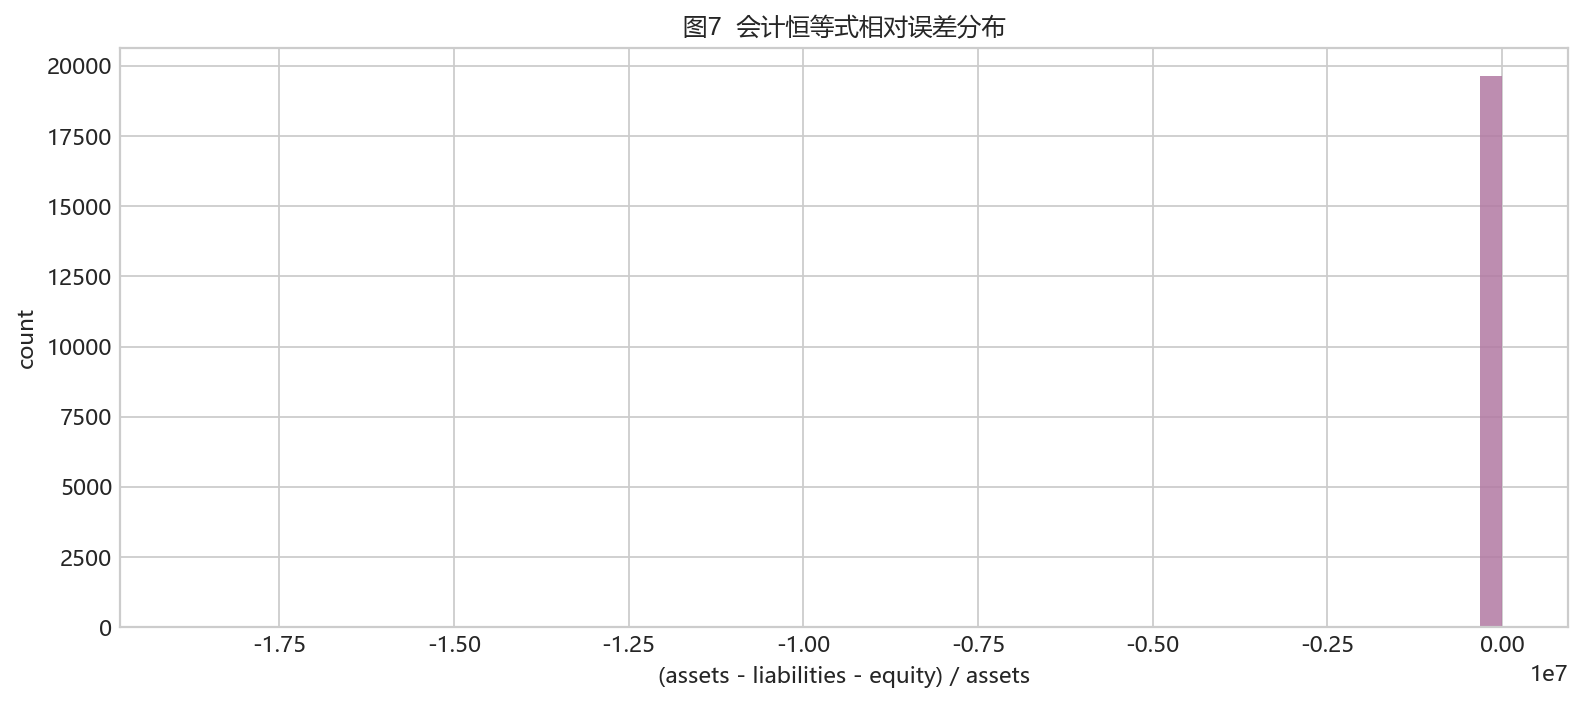

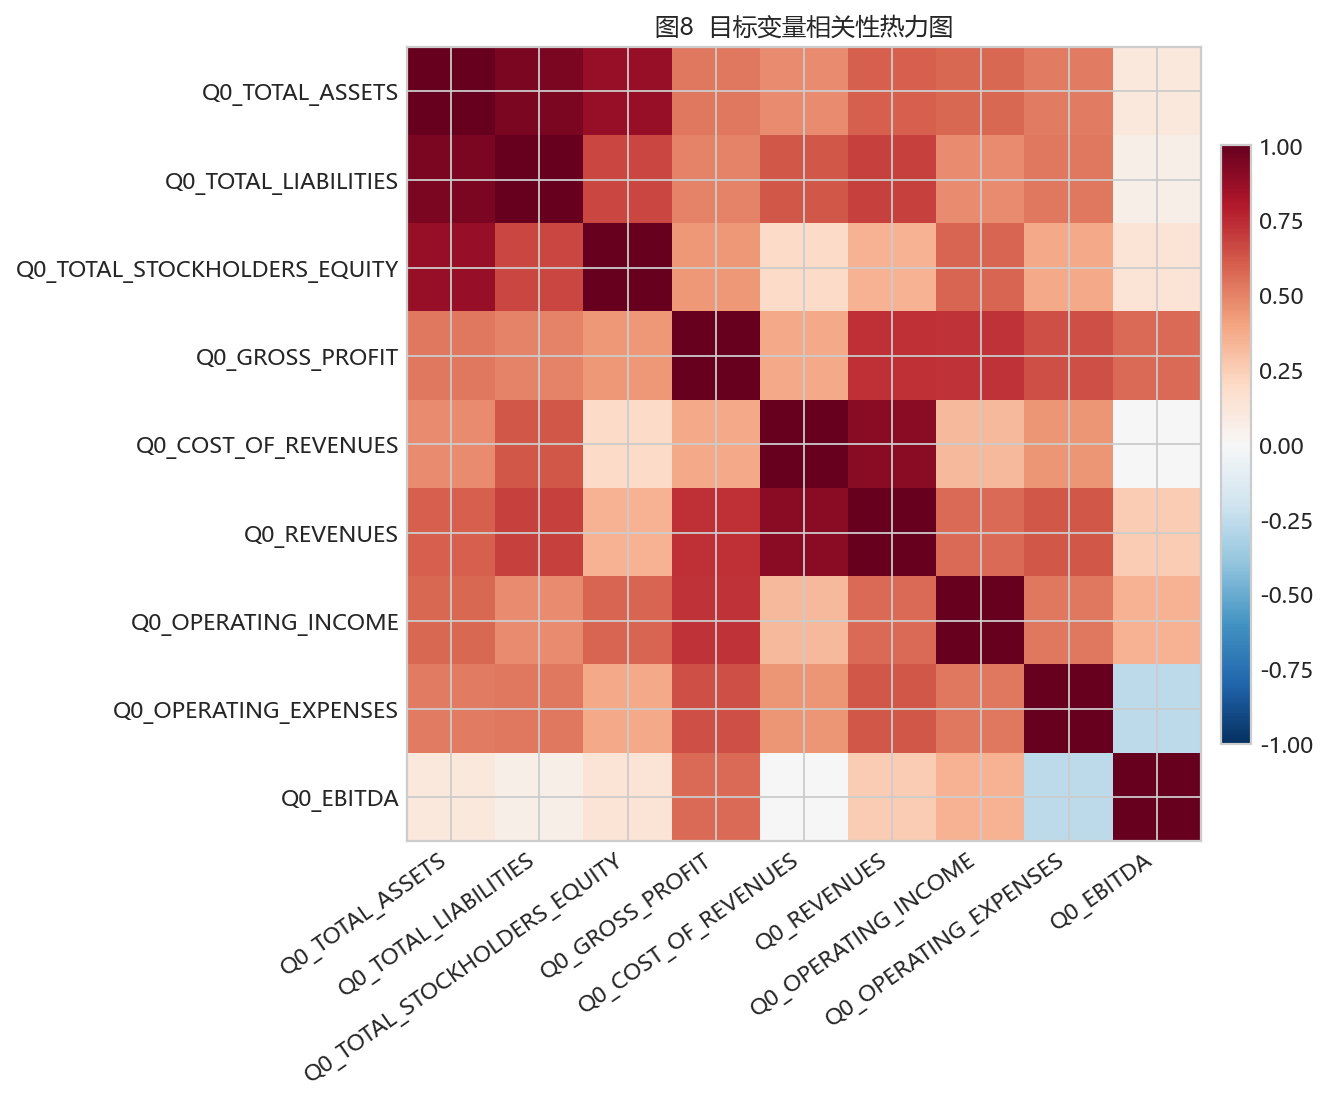

In [4]:
for fig in [
    'fig01_sector_distribution.png',
    'fig02_industry_top20.png',
    'fig03_missing_top20.png',
    'fig04_missing_by_quarter.png',
    'fig05_target_distributions.png',
    'fig06_lag_correlation_heatmap.png',
    'fig07_accounting_identity_error.png',
    'fig08_target_correlation_heatmap.png',
]:
    show_fig(fig)

## 4. 交叉验证与模型训练结果

,experiment_id,model_name,mean_r2,fold_mean_r2_std,runtime_seconds,notes,r2_Q0_TOTAL_ASSETS,r2_Q0_TOTAL_LIABILITIES,r2_Q0_TOTAL_STOCKHOLDERS_EQUITY,r2_Q0_GROSS_PROFIT,r2_Q0_COST_OF_REVENUES,r2_Q0_REVENUES,r2_Q0_OPERATING_INCOME,r2_Q0_OPERATING_EXPENSES,r2_Q0_EBITDA,feature_set,target_strategy
0,B0,B0_baseline,-0.001160,0.003979,0.025154,GroupKFold OOF baseline,-0.002034,-0.000381,-0.005128,-0.000618,-0.000080,-0.000261,-0.000319,-0.001343,-0.000274,NaN,NaN
1,B1,B1_baseline,0.722641,0.103267,0.105383,GroupKFold OOF baseline,0.371712,0.635722,-0.144362,0.982581,0.961402,0.972734,0.782711,0.982136,0.959135,NaN,NaN
2,B2,B2_baseline,0.331501,0.468760,0.113610,GroupKFold OOF baseline,0.558741,0.861749,-0.064400,0.463785,0.848445,0.661681,-1.582001,0.915689,0.319823,NaN,NaN
3,B3,B3_baseline,0.500414,0.211648,0.547052,GroupKFold OOF baseline,0.227375,0.411075,-0.168826,0.770293,0.841569,0.800554,-0.053005,0.933846,0.740850,NaN,NaN
4,B4,B4_baseline,0.783083,0.129085,2.092509,GroupKFold OOF baseline,0.558741,0.861749,-0.052960,0.982581,0.964017,0.972798,0.811722,0.987095,0.962009,NaN,NaN
5,M1_ridge_history_raw,Ridge,0.731390,0.190283,6.598222,GroupKFold OOF sklearn baseline,0.689456,0.869536,0.251245,0.894842,0.798790,0.838821,0.506584,0.871708,0.861531,history_raw,direct
6,M2_hgb_history_raw,HistGradientBoostingRegressor,0.497172,0.114549,107.401618,GroupKFold OOF sklearn baseline,0.333601,0.499702,-0.057153,0.693333,0.762675,0.832240,0.549956,0.558643,0.301547,history_raw,direct
7,M3_catboost_direct_history_metadata_engineered,CatBoostRegressor,0.609040,0.433507,554.514580,CatBoost direct on history_metadata_engineered...,0.635595,0.694450,0.400867,0.762139,0.858348,0.896821,0.510147,0.601240,0.121757,history_metadata_engineered,direct
8,M4_catboost_residual_history_metadata_engineered,CatBoostRegressor,0.825250,1.120254,330.111681,CatBoost residual on history_metadata_engineer...,0.673112,0.911213,0.143782,0.984133,0.964448,0.972867,0.826807,0.987128,0.963759,history_metadata_engineered,residual
9,M3a_catboost_direct_history_raw,CatBoostRegressor,0.554307,0.700440,56.118523,CatBoost direct on history_raw | best_iters=180,0.543295,0.642867,0.215742,0.731811,0.838717,0.876313,0.465158,0.548385,0.126478,history_raw,direct


,experiment_id,model_name,feature_set,target_strategy,mean_r2,fold_mean_r2_std,runtime_seconds,notes,r2_Q0_TOTAL_ASSETS,r2_Q0_TOTAL_LIABILITIES,r2_Q0_TOTAL_STOCKHOLDERS_EQUITY,r2_Q0_GROSS_PROFIT,r2_Q0_COST_OF_REVENUES,r2_Q0_REVENUES,r2_Q0_OPERATING_INCOME,r2_Q0_OPERATING_EXPENSES,r2_Q0_EBITDA
0,M6_oof_blend,OOFWeightedBlend,saved_oof_predictions,per_target_oof_blend,0.857227,0.049048,18.989362,"Per-target OOF blend of B4, M3d, and M4; weigh...",0.703489,0.911213,0.400867,0.984133,0.964448,0.972883,0.826807,0.987441,0.963759
1,M7_accounting_postprocess,AccountingPostprocess,saved_oof_predictions,none,0.857227,0.049048,18.989362,OOF-selected accounting adjustment: none.,0.703489,0.911213,0.400867,0.984133,0.964448,0.972883,0.826807,0.987441,0.963759


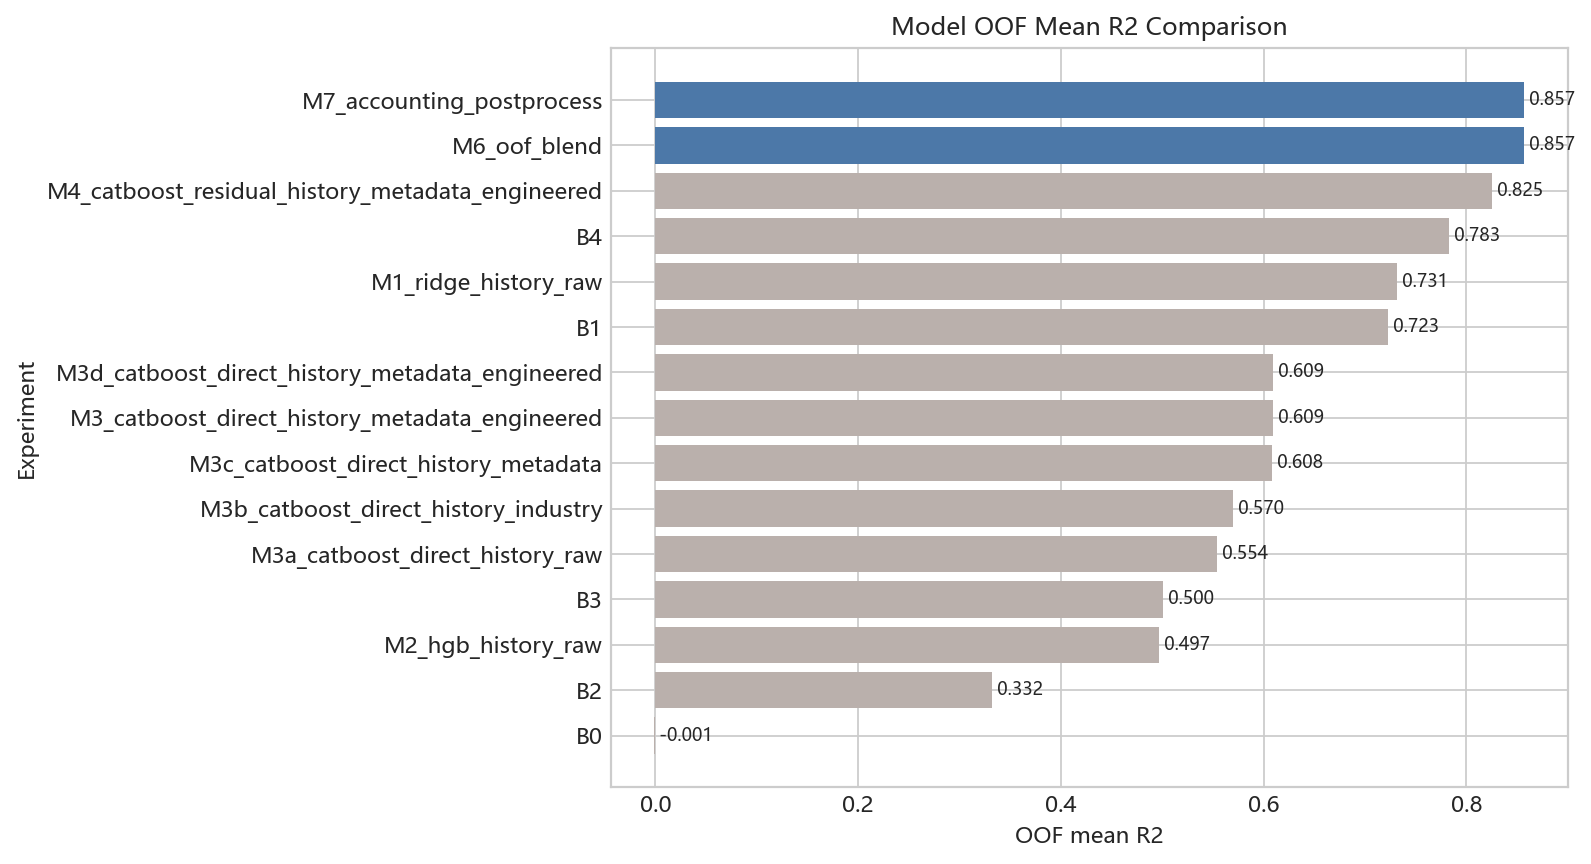

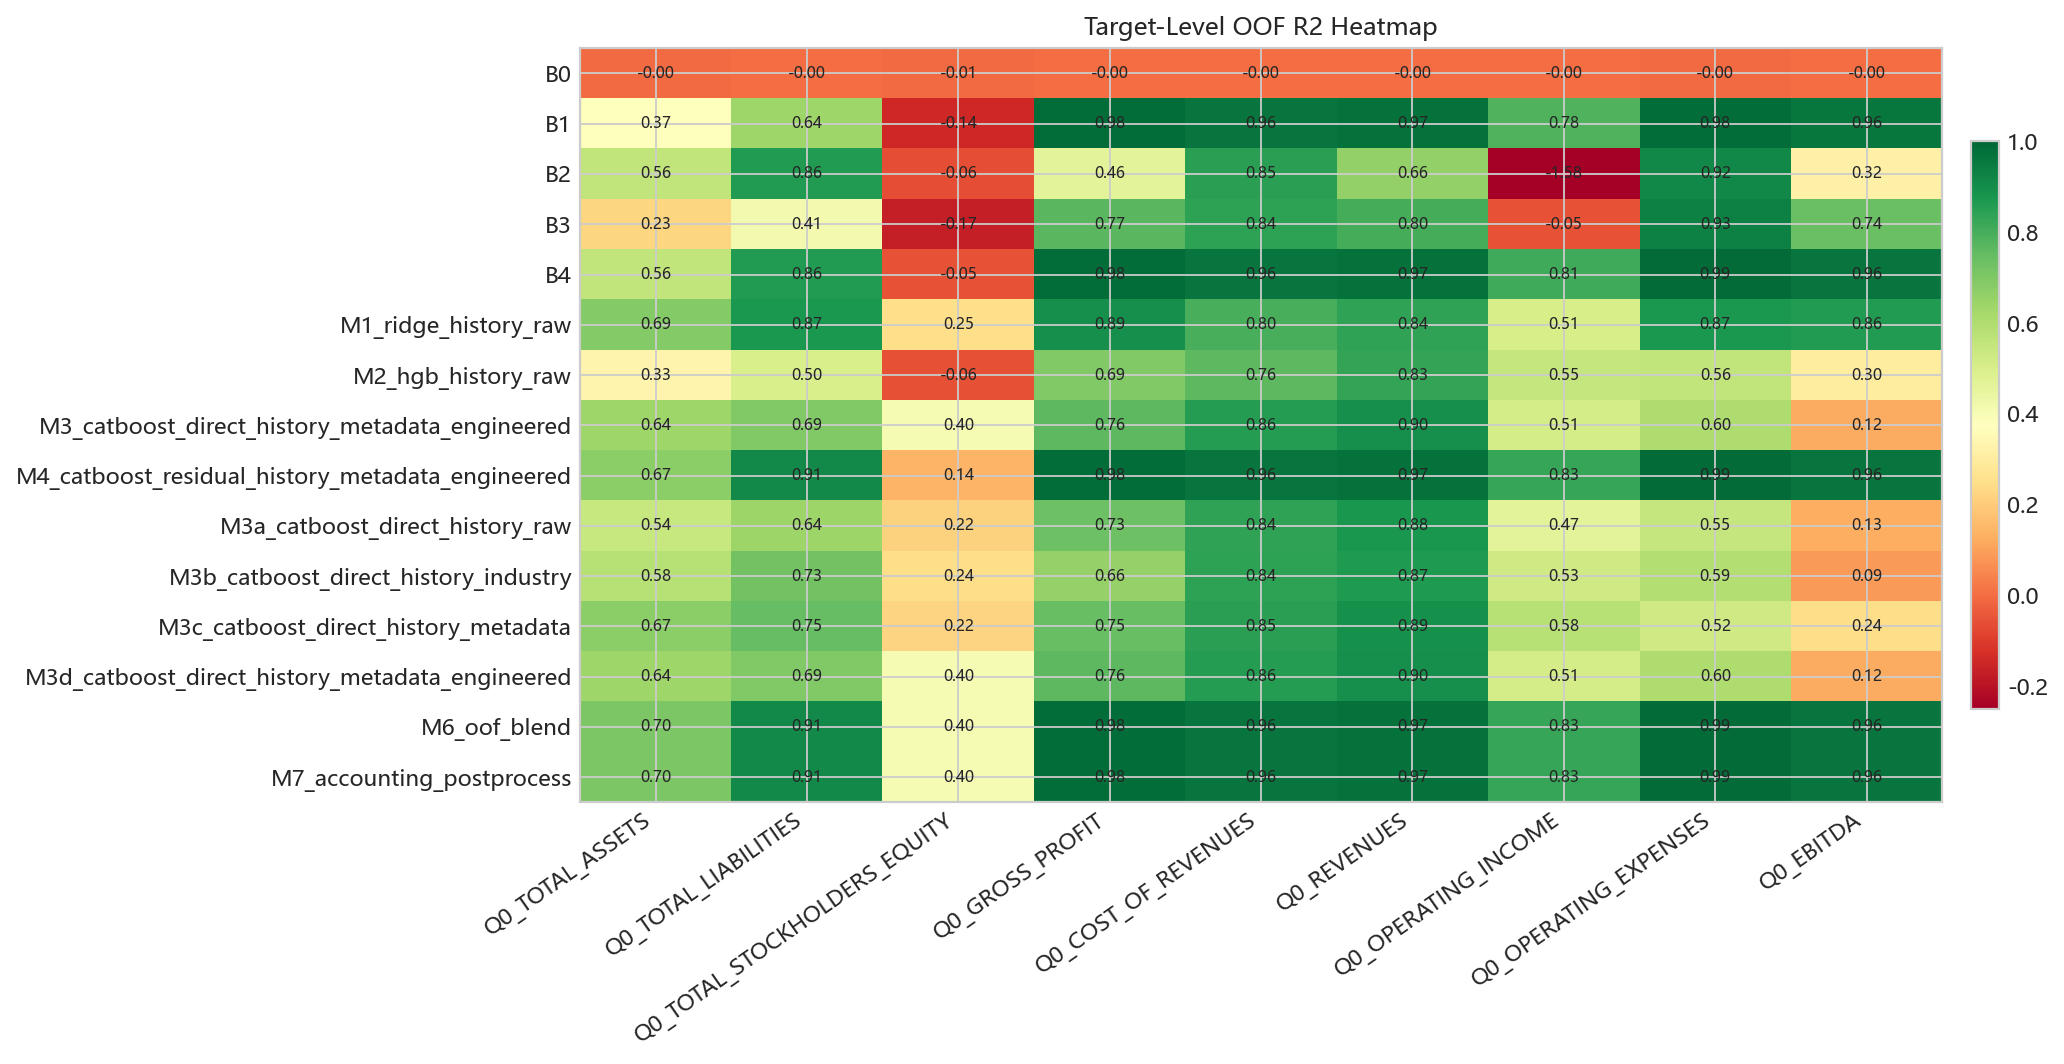

WindowsPath('D:/PyCharm/Quant/financial-performance-prediction/figures/fig10_target_score_heatmap.png')

In [5]:
all_scores = show_table(TABLES / 'all_model_scores.csv', n=20)
final_scores = show_table(TABLES / 'final_model_scores.csv')
show_fig('fig09_model_comparison.png')
show_fig('fig10_target_score_heatmap.png')

## 5. OOF 融合与会计后处理

,target,members,weights,oof_r2,coarse_step,fine_step,fine_radius
0,Q0_TOTAL_ASSETS,"B4,M3d,M4","0.00,0.40,0.60",0.703489,0.05,0.01,0.05
1,Q0_TOTAL_LIABILITIES,"B4,M3d,M4","0.00,0.00,1.00",0.911213,0.05,0.01,0.05
2,Q0_TOTAL_STOCKHOLDERS_EQUITY,"B4,M3d,M4","0.00,1.00,0.00",0.400867,0.05,0.01,0.05
3,Q0_GROSS_PROFIT,"B4,M3d,M4","0.00,0.00,1.00",0.984133,0.05,0.01,0.05
4,Q0_COST_OF_REVENUES,"B4,M3d,M4","0.00,0.00,1.00",0.964448,0.05,0.01,0.05
5,Q0_REVENUES,"B4,M3d,M4","0.30,0.00,0.70",0.972883,0.05,0.01,0.05
6,Q0_OPERATING_INCOME,"B4,M3d,M4","0.00,0.00,1.00",0.826807,0.05,0.01,0.05
7,Q0_OPERATING_EXPENSES,"B4,M3d,M4","0.97,0.03,0.00",0.987441,0.05,0.01,0.05
8,Q0_EBITDA,"B4,M3d,M4","0.00,0.00,1.00",0.963759,0.05,0.01,0.05


,adjustment,mean_r2,r2_Q0_TOTAL_ASSETS,r2_Q0_TOTAL_LIABILITIES,r2_Q0_TOTAL_STOCKHOLDERS_EQUITY,r2_Q0_GROSS_PROFIT,r2_Q0_COST_OF_REVENUES,r2_Q0_REVENUES,r2_Q0_OPERATING_INCOME,r2_Q0_OPERATING_EXPENSES,r2_Q0_EBITDA
0,none,0.857227,0.703489,0.911213,0.400867,0.984133,0.964448,0.972883,0.826807,0.987441,0.963759
1,balance_sheet_equity,0.836744,0.703489,0.911213,0.216526,0.984133,0.964448,0.972883,0.826807,0.987441,0.963759
2,gross_profit_identity,0.854654,0.703489,0.911213,0.400867,0.960980,0.964448,0.972883,0.826807,0.987441,0.963759
3,operating_income_identity,0.362620,0.703489,0.911213,0.400867,0.984133,0.964448,0.972883,-3.624653,0.987441,0.963759
4,income_statement_identity,0.342141,0.703489,0.911213,0.400867,0.960980,0.964448,0.972883,-3.785815,0.987441,0.963759
5,balance_and_income_identity,0.321658,0.703489,0.911213,0.216526,0.960980,0.964448,0.972883,-3.785815,0.987441,0.963759


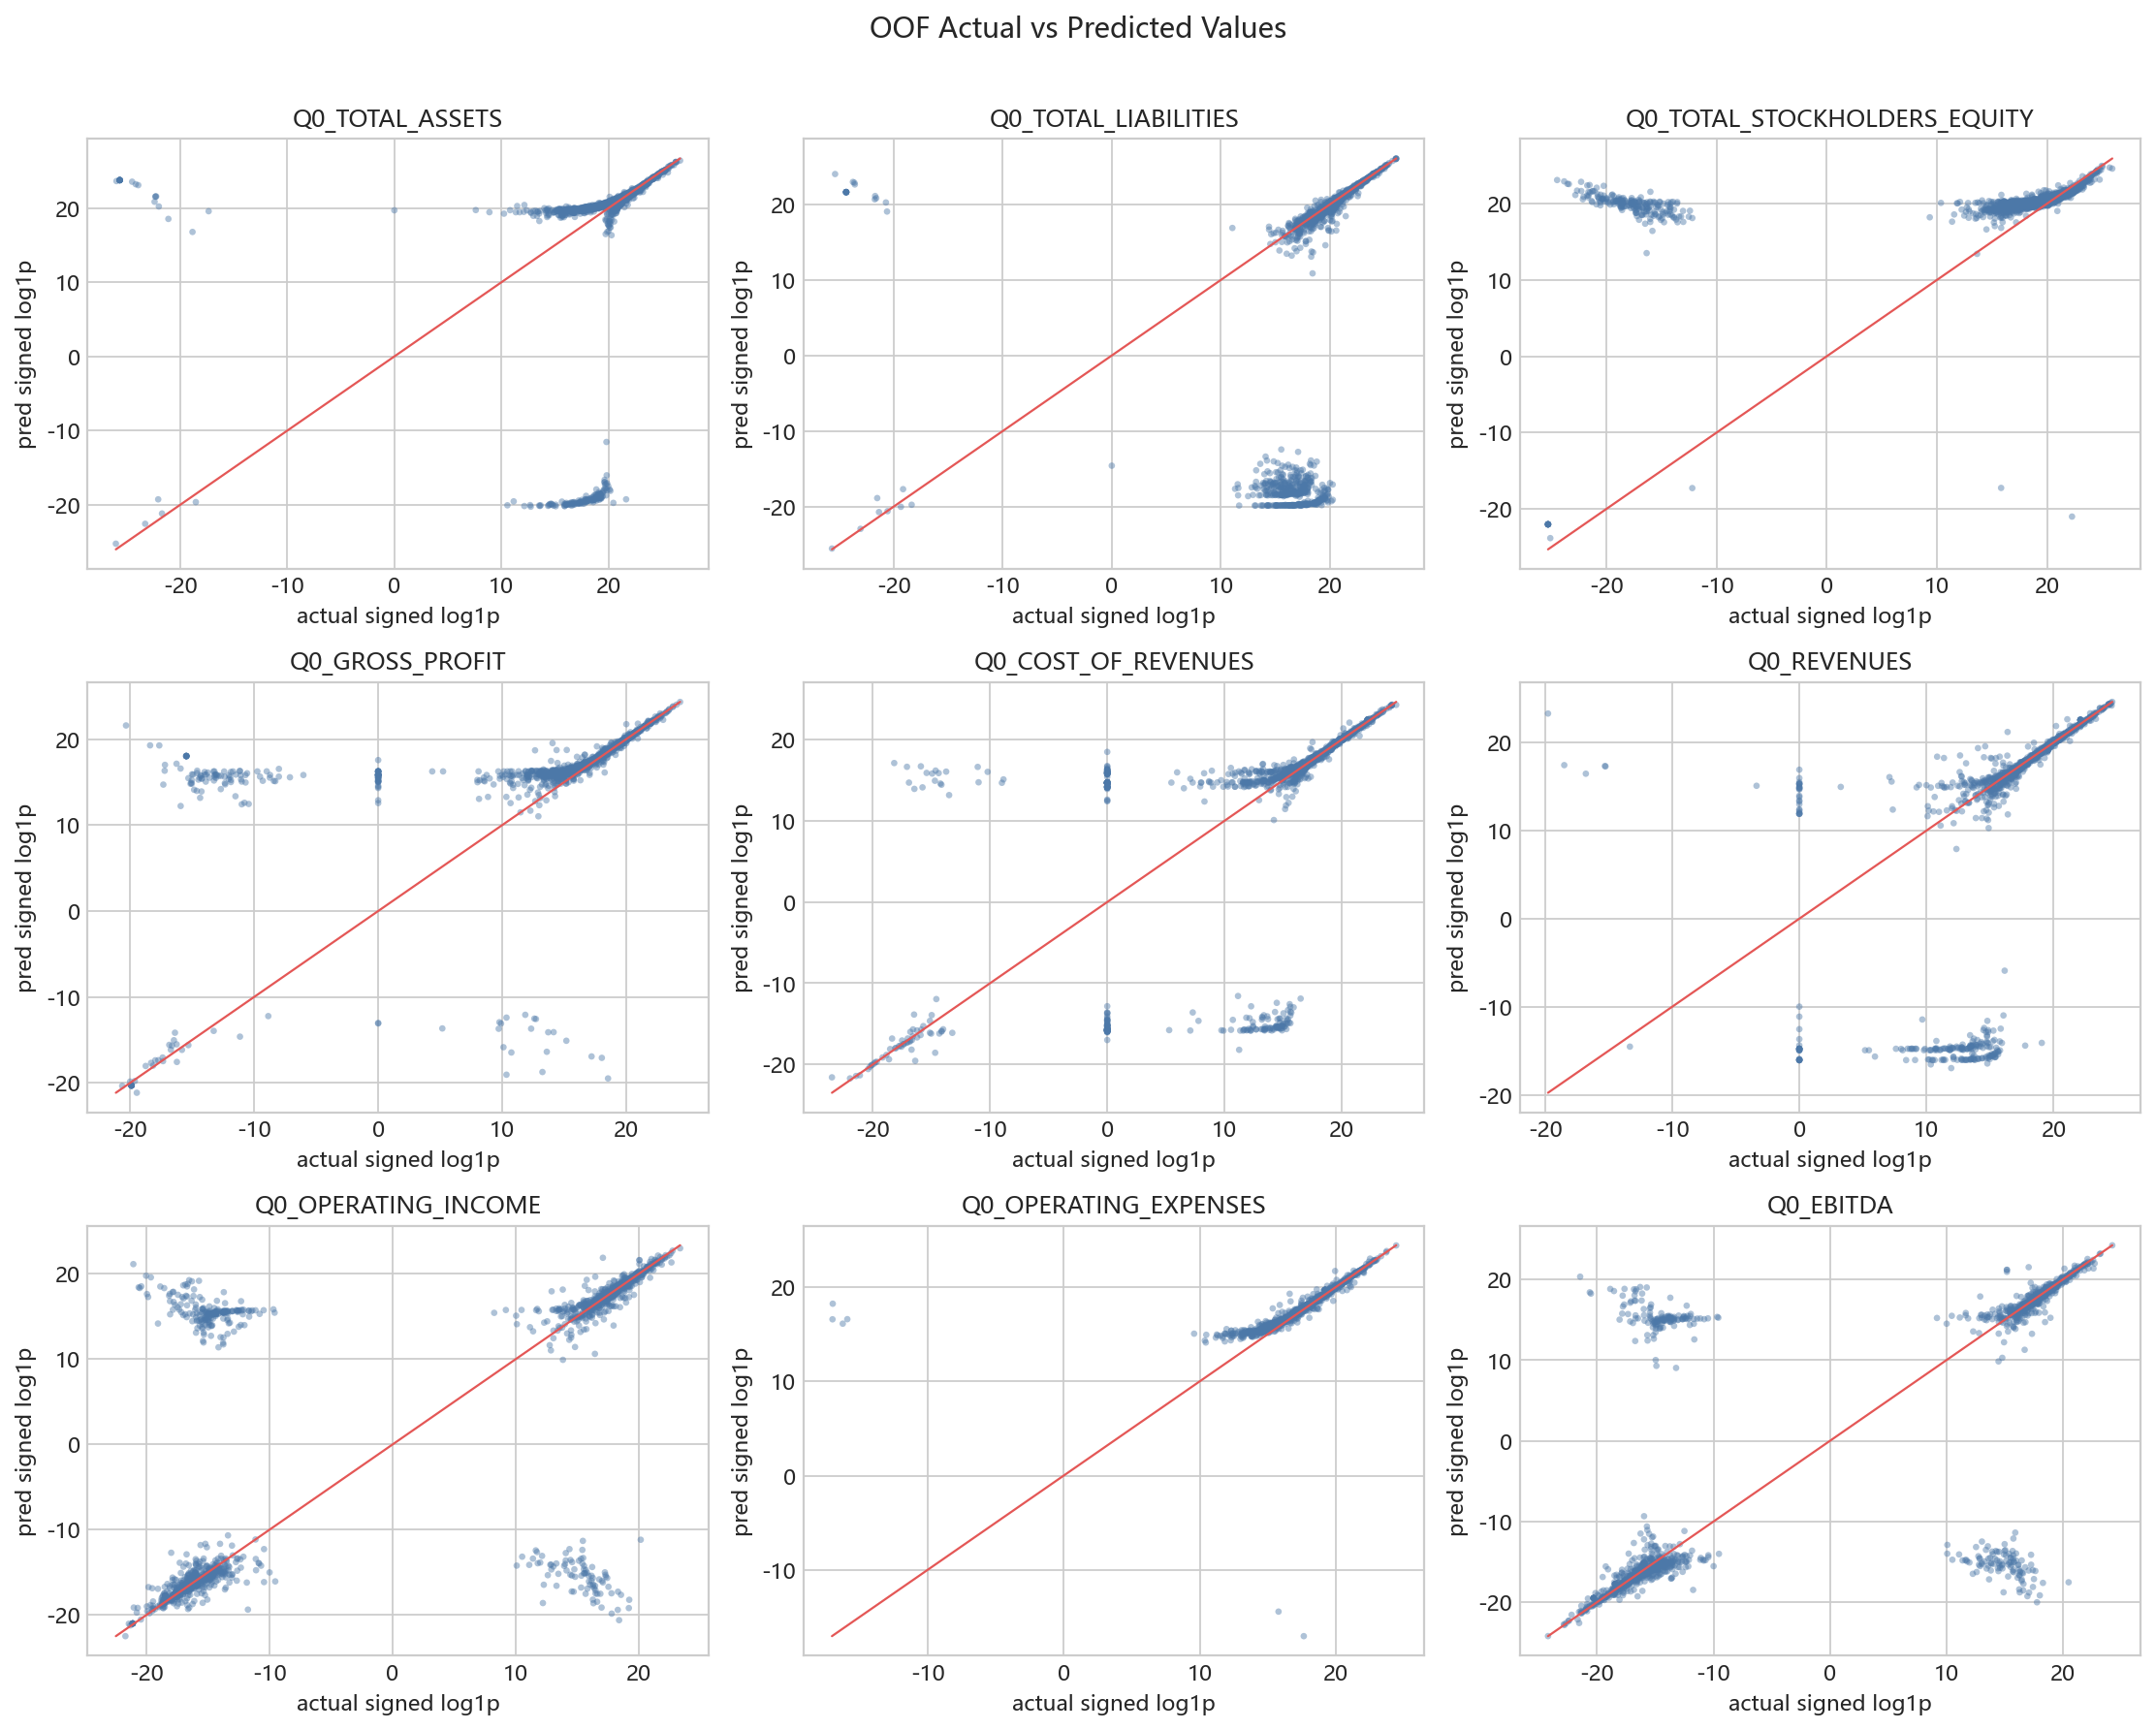

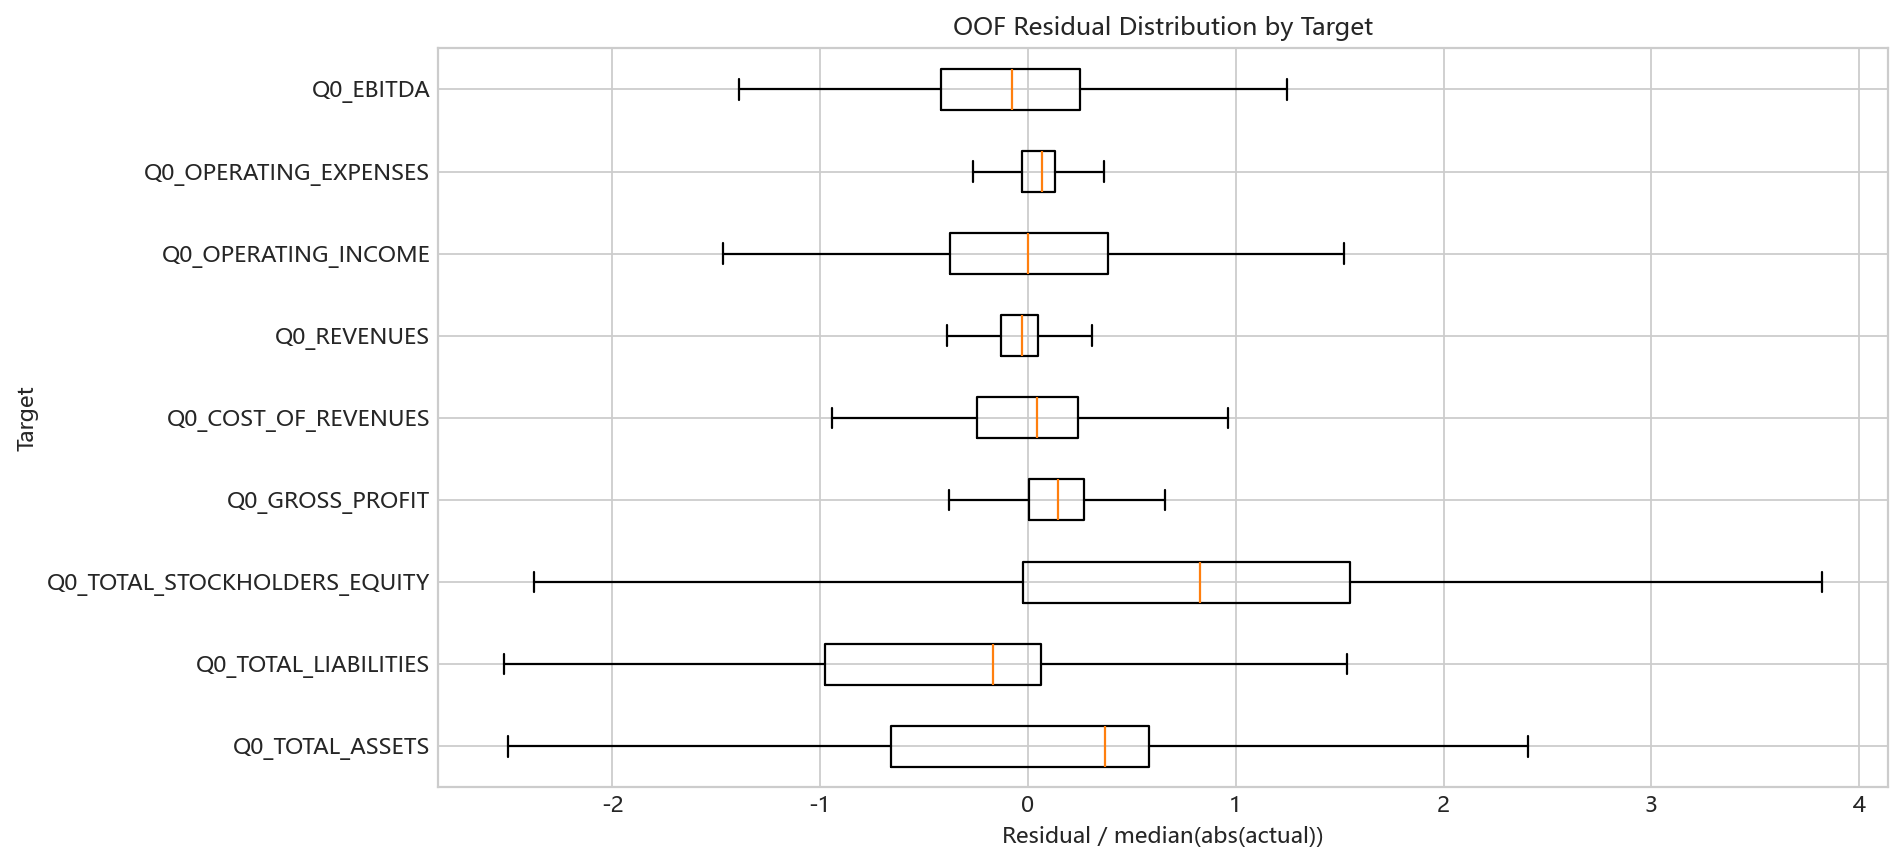

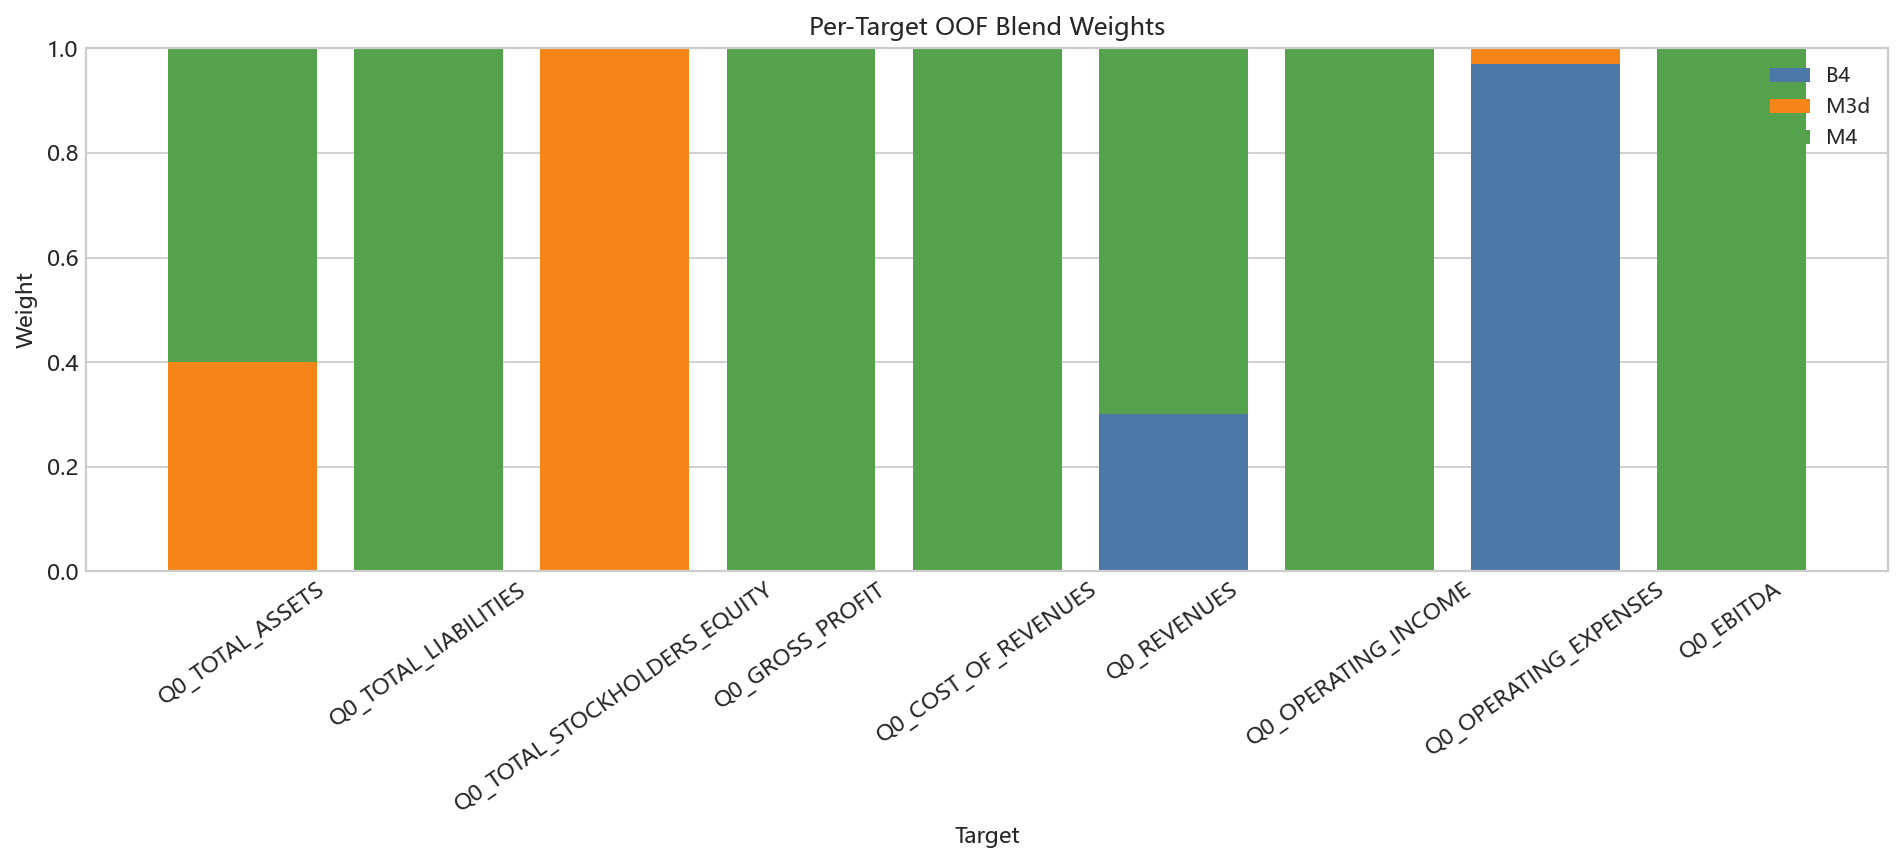

WindowsPath('D:/PyCharm/Quant/financial-performance-prediction/figures/fig13_blend_weights.png')

In [6]:
blend_scores = show_table(TABLES / 'blend_scores.csv')
accounting_scores = show_table(TABLES / 'accounting_postprocess_scores.csv')
show_fig('fig11_oof_scatter.png')
show_fig('fig12_residual_distribution.png')
show_fig('fig13_blend_weights.png')

## 6. Submission 校验

In [7]:
submission = pd.read_csv(DELIVERABLES / 'submission.csv')
sample = pd.read_csv(ROOT / 'sample_submission.csv')
assert submission.shape == sample.shape
assert list(submission.columns) == list(sample.columns)
assert submission['Id'].equals(sample['Id'])
values = submission.drop(columns=['Id'])
assert not values.isna().any().any()
assert values.applymap(lambda x: x == float('inf') or x == float('-inf')).sum().sum() == 0
print('submission rows, cols:', submission.shape)
print('submission sha256:', sha256_file(DELIVERABLES / 'submission.csv'))
submission.head()

submission rows, cols: (406, 10)
submission sha256: c8c777fb68ca7d363e218b8ff09d4d7eb2e189f92084523779bc0de9c947e97f


C:\Users\35494\AppData\Local\Temp\ipykernel_21456\3935019377.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  assert values.applymap(lambda x: x == float('inf') or x == float('-inf')).sum().sum() == 0


,Id,Q0_REVENUES,Q0_COST_OF_REVENUES,Q0_GROSS_PROFIT,Q0_OPERATING_EXPENSES,Q0_EBITDA,Q0_OPERATING_INCOME,Q0_TOTAL_ASSETS,Q0_TOTAL_LIABILITIES,Q0_TOTAL_STOCKHOLDERS_EQUITY
0,480,3.530662e+06,-8.162991e+04,5.950862e+06,3.927671e+06,-8.407525e+05,-1.997766e+06,3.241109e+08,-2.778244e+07,2.386787e+08
1,573,5.906039e+08,3.763365e+08,2.289284e+08,1.068949e+08,1.038408e+08,6.656993e+07,3.424342e+09,1.579155e+09,1.118248e+09
2,1967,9.266837e+07,-2.502636e+07,-1.950793e+06,3.071610e+06,-4.252383e+05,1.083416e+04,3.630764e+08,7.767078e+06,2.649837e+08
3,57,4.245573e+08,2.639009e+08,1.784814e+08,8.558952e+07,7.780357e+07,7.824407e+07,4.882171e+09,2.925416e+09,1.311259e+09
4,131,1.040944e+09,8.389861e+08,2.179588e+08,8.607366e+07,1.172300e+08,1.184286e+08,4.150832e+09,3.476632e+09,1.295593e+09
